# Phase 5 — Split Strategy (Panel-Aware Walk-Forward CV)

**เป้าหมายของ notebook นี้:** ออกแบบวิธีแบ่งข้อมูล train/validation/test ที่ถูกต้องสำหรับข้อมูลแบบ panel + time series ก่อนเริ่มสร้างโมเดลจริงใน Phase 6-7

**ทำไมแบ่งแบบสุ่ม (random split) ใช้ไม่ได้กับข้อมูลนี้:**
1. เป็น **time series** — ถ้าสุ่มแบ่ง โมเดลจะได้เห็นข้อมูล "อนาคต" ตอนเทรน แล้วไปทำนาย "อดีต" ตอน validate ซึ่งไม่ตรงกับสถานการณ์จริงที่ต้องพยากรณ์ไปข้างหน้าเท่านั้น
2. เป็น **panel data** (sku × channel × region × week) — ถ้าแบ่งแบบสุ่มตาม row index อาจมีบาง row ของสัปดาห์เดียวกัน (เช่น sku เดียวกัน แต่คนละ channel) หลุดไปอยู่ทั้งฝั่ง train และ validation พร้อมกัน ทำให้ evaluation ไม่สะท้อนสถานการณ์จริง (โมเดลควรพยากรณ์ "สัปดาห์ทั้งสัปดาห์ที่ยังไม่เคยเห็น" ไม่ใช่บาง cell ของสัปดาห์นั้น)

ดังนั้นการแบ่งข้อมูลต้อง **แบ่งตาม `week` เท่านั้น** (ไม่ใช่ row index) เพื่อให้ทุก sku-channel-region ของสัปดาห์เดียวกันอยู่ฝั่งเดียวกันเสมอ — โค้ดหลักอยู่ใน `src/splits/walk_forward.py`


In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

from splits.walk_forward import WalkForwardSplitter, get_sorted_weeks

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

PROCESSED = Path('../data/processed')
FIG = Path('../reports/figures')


In [2]:
df = pd.read_csv(PROCESSED / 'weekly_features.csv', parse_dates=['week'])
print('shape:', df.shape)

weeks = get_sorted_weeks(df)
print(f'ช่วงข้อมูลทั้งหมด: {len(weeks)} สัปดาห์ ({pd.Timestamp(weeks[0]).date()} ถึง {pd.Timestamp(weeks[-1]).date()})')


shape: (31027, 40)
ช่วงข้อมูลทั้งหมด: 150 สัปดาห์ (2022-02-14 ถึง 2024-12-23)


## 1. ออกแบบ Scheme

| ส่วน | ช่วงเวลา | ใช้ทำอะไร |
|---|---|---|
| **Initial training window** | 2022-02-14 → 2023-09-25 (85 สัปดาห์) | จุดเริ่มต้นของทุก fold |
| **Walk-forward validation folds** | 2023-10-02 → 2024-10-14 (expanding, ทีละ 8 สัปดาห์) | จูน/เทียบโมเดลหลายตัวระหว่างพัฒนา (Phase 6-11) |
| **Final holdout test** | 2024-10-21 → 2024-12-23 (10 สัปดาห์สุดท้าย) | ใช้ครั้งเดียวตอน Phase 13 เท่านั้น ห้ามแตะระหว่างพัฒนาโมเดล |

**Expanding window** หมายถึง train set ของแต่ละ fold จะ**ขยายขึ้นเรื่อยๆ** ไม่ใช่เลื่อนขนาดคงที่ (sliding window) — เพราะจำลองสถานการณ์จริงที่เมื่อเวลาผ่านไป เรามีข้อมูลอดีตสะสมมากขึ้นเรื่อยๆ ให้เทรนโมเดลใหม่ ไม่ใช่ทิ้งข้อมูลเก่า


In [3]:
splitter = WalkForwardSplitter(initial_train_end='2023-09-30', val_fold_weeks=8, final_test_weeks=10)
folds, final_test_weeks = splitter.get_folds(df)

summary = pd.DataFrame([
    {
        'fold': f.fold_id,
        'train_weeks': len(f.train_weeks),
        'train_start': pd.Timestamp(f.train_weeks[0]).date(),
        'train_end': pd.Timestamp(f.train_weeks[-1]).date(),
        'val_weeks': len(f.val_weeks),
        'val_start': pd.Timestamp(f.val_weeks[0]).date(),
        'val_end': pd.Timestamp(f.val_weeks[-1]).date(),
    }
    for f in folds
])
summary


,fold,train_weeks,train_start,train_end,val_weeks,val_start,val_end
0,0,85,2022-02-14,2023-09-25,8,2023-10-02,2023-11-20
1,1,93,2022-02-14,2023-11-20,8,2023-11-27,2024-01-15
2,2,101,2022-02-14,2024-01-15,8,2024-01-22,2024-03-11
3,3,109,2022-02-14,2024-03-11,8,2024-03-18,2024-05-06
4,4,117,2022-02-14,2024-05-06,8,2024-05-13,2024-07-01
5,5,125,2022-02-14,2024-07-01,8,2024-07-08,2024-08-26
6,6,133,2022-02-14,2024-08-26,7,2024-09-02,2024-10-14


## 2. Diagram ของ Scheme

แผนภาพแสดง fold ทั้งหมด — สีน้ำเงิน = training window (ขยายขึ้นเรื่อยๆ), สีส้ม = validation window ของแต่ละ fold, สีเทา = final holdout test ที่ไม่แตะเลยจนถึง Phase 13


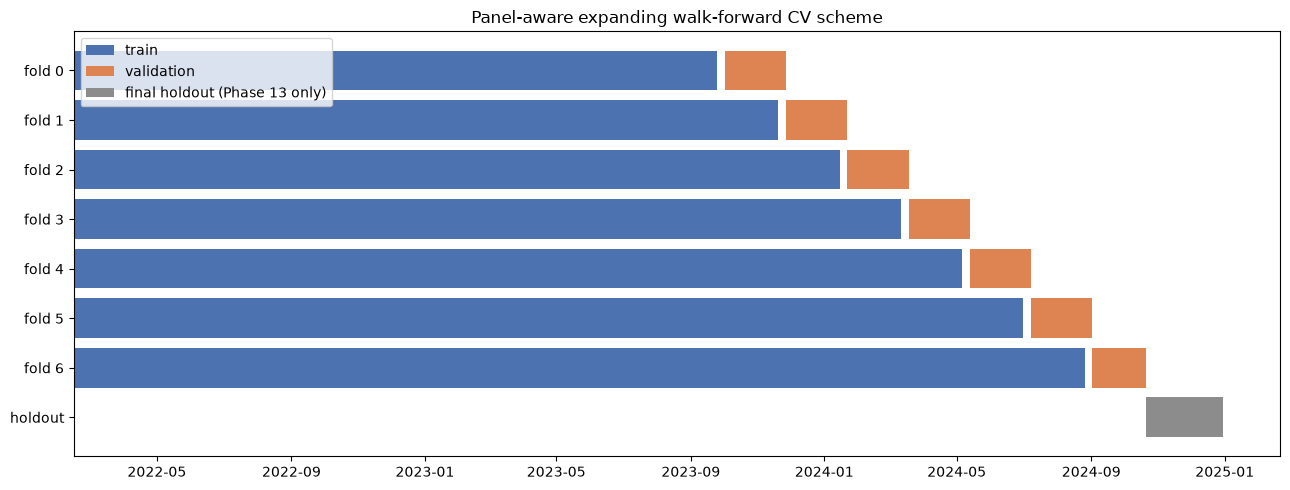

In [4]:
fig, ax = plt.subplots(figsize=(13, 5))

bar_height = 0.8
for f in folds:
    train_start, train_end = pd.Timestamp(f.train_weeks[0]), pd.Timestamp(f.train_weeks[-1])
    val_start, val_end = pd.Timestamp(f.val_weeks[0]), pd.Timestamp(f.val_weeks[-1])
    y = f.fold_id
    ax.barh(y, (train_end - train_start).days, left=train_start, height=bar_height, color='#4C72B0', label='train' if y == 0 else None)
    ax.barh(y, (val_end - val_start).days + 7, left=val_start, height=bar_height, color='#DD8452', label='validation' if y == 0 else None)

test_start, test_end = pd.Timestamp(final_test_weeks[0]), pd.Timestamp(final_test_weeks[-1])
ax.barh(len(folds), (test_end - test_start).days + 7, left=test_start, height=bar_height, color='#8C8C8C', label='final holdout (Phase 13 only)')

ax.set_yticks(list(range(len(folds))) + [len(folds)])
ax.set_yticklabels([f'fold {f.fold_id}' for f in folds] + ['holdout'])
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.set_title('Panel-aware expanding walk-forward CV scheme')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig(FIG / 'phase5_walk_forward_scheme.png', dpi=120)
plt.show()


## 3. ตรวจสอบความถูกต้องของ Split (Sanity Checks)

ต้องยืนยัน 3 เรื่อง: (1) train/validation ไม่มีแถวซ้ำกัน (2) ทุกแถวใน train เกิดขึ้นก่อนทุกแถวใน validation เสมอ (3) final holdout แยกออกจาก CV โดยสมบูรณ์ ไม่มีสัปดาห์ไหนอยู่ทั้งสองฝั่ง


In [5]:
all_ok = True
for train_idx, val_idx in splitter.split(df):
    overlap = set(train_idx) & set(val_idx)
    train_weeks_in_fold = df.loc[train_idx, 'week']
    val_weeks_in_fold = df.loc[val_idx, 'week']
    ok = (len(overlap) == 0) and (train_weeks_in_fold.max() < val_weeks_in_fold.min())
    all_ok = all_ok and ok

cv_idx, test_idx = splitter.final_test_split(df)
no_overlap = len(set(cv_idx) & set(test_idx)) == 0
covers_all = (len(cv_idx) + len(test_idx)) == len(df)
cv_before_test = df.loc[cv_idx, 'week'].max() < df.loc[test_idx, 'week'].min()

print(f'ทุก fold: train/val ไม่ซ้ำกันและ train มาก่อน val เสมอ: {all_ok}')
print(f'final holdout: ไม่ซ้ำกับ CV: {no_overlap}, ครอบคลุมทุกแถว: {covers_all}, CV มาก่อน holdout เสมอ: {cv_before_test}')


ทุก fold: train/val ไม่ซ้ำกันและ train มาก่อน val เสมอ: True
final holdout: ไม่ซ้ำกับ CV: True, ครอบคลุมทุกแถว: True, CV มาก่อน holdout เสมอ: True


**ผลลัพธ์:** ผ่านทุกเช็ค — scheme นี้ปลอดภัยจาก temporal leakage และ panel leakage รับประกันได้ว่าทุกโมเดลที่ทดสอบใน Phase 6-13 จะถูกประเมินด้วยมาตรฐานเดียวกัน


## 4. สรุป Phase 5

| หัวข้อ | ผลลัพธ์ |
|---|---|
| วิธีแบ่ง | Time-based, แบ่งตาม `week` เท่านั้น (panel-aware — ไม่แบ่งตาม row index) |
| Scheme | Expanding walk-forward: train เริ่มต้น 85 สัปดาห์ (2022-02→2023-09), ขยายทีละ 8 สัปดาห์ ทำซ้ำ 7 fold |
| Final holdout | 10 สัปดาห์สุดท้ายของปี 2024 (2024-10-21→2024-12-23) — ไม่แตะจนกว่าจะถึง Phase 13 |
| Sanity checks | ผ่านทุกเช็ค: ไม่มี overlap, ลำดับเวลาถูกต้องเสมอ |
| Output | `src/splits/walk_forward.py` (`WalkForwardSplitter` — sklearn-style `.split()`), `reports/figures/phase5_walk_forward_scheme.png` |

### ขั้นตอนต่อไป (Phase 6 — Baseline Models)
ใช้ `WalkForwardSplitter` นี้ประเมิน naive, seasonal naive, และ moving average บนทุก fold เพื่อสร้าง baseline scoreboard ก่อนเริ่มโมเดล ML จริงใน Phase 7
